<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
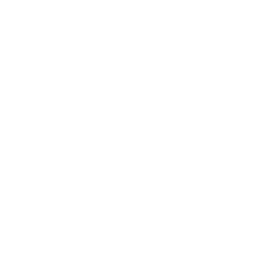
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Balanced Scorecard Metric Normalization for PCA</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Retail Analytics / Performance Management &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

Standardize revenue, gross margin, foot traffic, conversion rate, and average basket size across 100 store locations to build a balanced performance scorecard. Raw metrics span different units and orders of magnitude — revenue near $1.4M, conversion rate around 22%, traffic in the tens of thousands. PROC STANDARD rescales all five to mean 0 and standard deviation 1 so that PROC PRINCOMP can extract principal components on equal footing, without revenue's enormous variance dominating the decomposition purely because of scale. The standardized inputs feed a principal component analysis whose leading component separates high-volume formats from high-margin formats and explains 77% of the variance across the scorecard.


## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.STORE_METRICS | Current-quarter performance scorecard, one row per store | 100 |

Each store carries two latent performance traits — a volume trait and a margin/premium trait — that jointly drive its five metrics, so the scorecard columns share real correlation structure for the principal component analysis to recover. Store format (SUPERSTORE, STANDARD, EXPRESS) is tied to those traits, giving three evenly represented format groups.


---

In [1]:
/* --------------------------------------------------------
   Generate a store performance scorecard: one row per store,
   100 stores, current-quarter metrics.

   Each store carries two latent performance traits that
   drive its five scorecard metrics, so the metrics share
   real correlation structure for PCA to recover:
     volume  -> revenue up, foot traffic up, conversion up
     premium -> gross margin up, basket up, traffic down
   Store format is tied to the traits: SUPERSTORE leans
   high-volume / low-margin, EXPRESS leans the opposite,
   STANDARD sits in the middle.
   -------------------------------------------------------- */
data work.store_metrics;
    call streaminit(42);
    length store_id $8 store_format $12 metro_area $15;
    array formats[3]  $12 _temporary_ ('SUPERSTORE' 'STANDARD' 'EXPRESS');
    array metros[5]   $15 _temporary_ ('NEW_YORK' 'CHICAGO' 'DALLAS' 'SEATTLE' 'ATLANTA');
    /* Format-level latent trait centers (volume, premium) */
    array fmt_vol[3]  _temporary_ ( 0.95  0.00 -0.95);
    array fmt_prm[3]  _temporary_ (-0.75  0.00  0.85);
    report_quarter = '01JAN2025'd;
    format report_quarter monyy7.;
    do store_num = 1 to 100;
        store_id = cat('S-', put(store_num, z4.));
        /* Rotate formats so all three are evenly represented */
        fmt_idx = mod(store_num - 1, 3) + 1;
        store_format = formats[fmt_idx];
        met_idx = int(rand('uniform') * 5) + 1;
        metro_area = metros[met_idx];
        /* Store-level latent traits: format center plus noise */
        volume  = fmt_vol[fmt_idx]  + rand('normal', 0, 0.55);
        premium = fmt_prm[fmt_idx]  + rand('normal', 0, 0.55);
        /* Quarterly revenue ($) driven by store volume */
        monthly_revenue = round(1450000 + 480000 * volume +
            rand('normal', 0, 90000), 1);
        if monthly_revenue < 100000 then monthly_revenue = 100000;
        /* Gross margin (%) - premium stores run richer margins */
        gross_margin_pct = round(32 + 5.0 * premium +
            rand('normal', 0, 2.0), 0.1);
        if gross_margin_pct < 10 then gross_margin_pct = 10;
        if gross_margin_pct > 55 then gross_margin_pct = 55;
        /* Foot traffic (visitor count) - high volume, low premium */
        foot_traffic = int(19000 + 6500 * volume - 2600 * premium +
            rand('normal', 0, 1600));
        if foot_traffic < 1000 then foot_traffic = 1000;
        /* Conversion rate (%) - higher in high-volume stores */
        conversion_rate = round(22 + 3.0 * volume +
            rand('normal', 0, 3.0), 0.1);
        if conversion_rate < 5 then conversion_rate = 5;
        if conversion_rate > 45 then conversion_rate = 45;
        /* Average basket size ($) - premium stores spend more */
        avg_basket = round(48 + 9.0 * premium +
            rand('normal', 0, 5.0), 0.01);
        if avg_basket < 10 then avg_basket = 10;
        output;
    end;
    drop store_num fmt_idx met_idx volume premium;
run;


NOTE: DATA work.store_metrics


NOTE: Wrote work.store_metrics (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline metric ranges showing scale differences
   -------------------------------------------------------- */
proc means data=work.store_metrics n mean std min max;
    var monthly_revenue gross_margin_pct foot_traffic
        conversion_rate avg_basket;
run;

                                                  The MEANS Procedure

 Variable                 N                Mean            Std Dev            Minimum             Maximum
 --------------------------------------------------------------------------------------------------------
 MONTHLY_REVENUE        100     1439667.3500000     498016.8512634     512808.0000000     2556834.0000000
 GROSS_MARGIN_PCT       100          31.9360000          4.6654223         20.2000000          42.2000000
 FOOT_TRAFFIC           100       18953.0400000       8435.4197885       2970.0000000       34216.0000000
 CONVERSION_RATE        100          21.8180000          4.3928634         11.1000000          30.2000000
 AVG_BASKET             100          47.7574000          9.5264423         31.3600000          67.4500000
 --------------------------------------------------------------------------------------------------------



NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

   Pearson Correlation Coefficients, N = 100
          monthly_revenuegross_margin_pctfoot_trafficconversion_rateavg_basket
--------  --------  --------  --------  --------  --------
monthly_revenue   1.00000  -0.61915   0.94814   0.71455  -0.56625
gross_margin_pct  -0.61915   1.00000  -0.72493  -0.47387   0.79468
foot_traffic   0.94814  -0.72493   1.00000   0.72227  -0.68513
conversion_rate   0.71455  -0.47387   0.72227   1.00000  -0.40541
avg_basket  -0.56625   0.79468  -0.68513  -0.40541   1.00000


NOTE: PROC CORR data=work.store_metrics

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


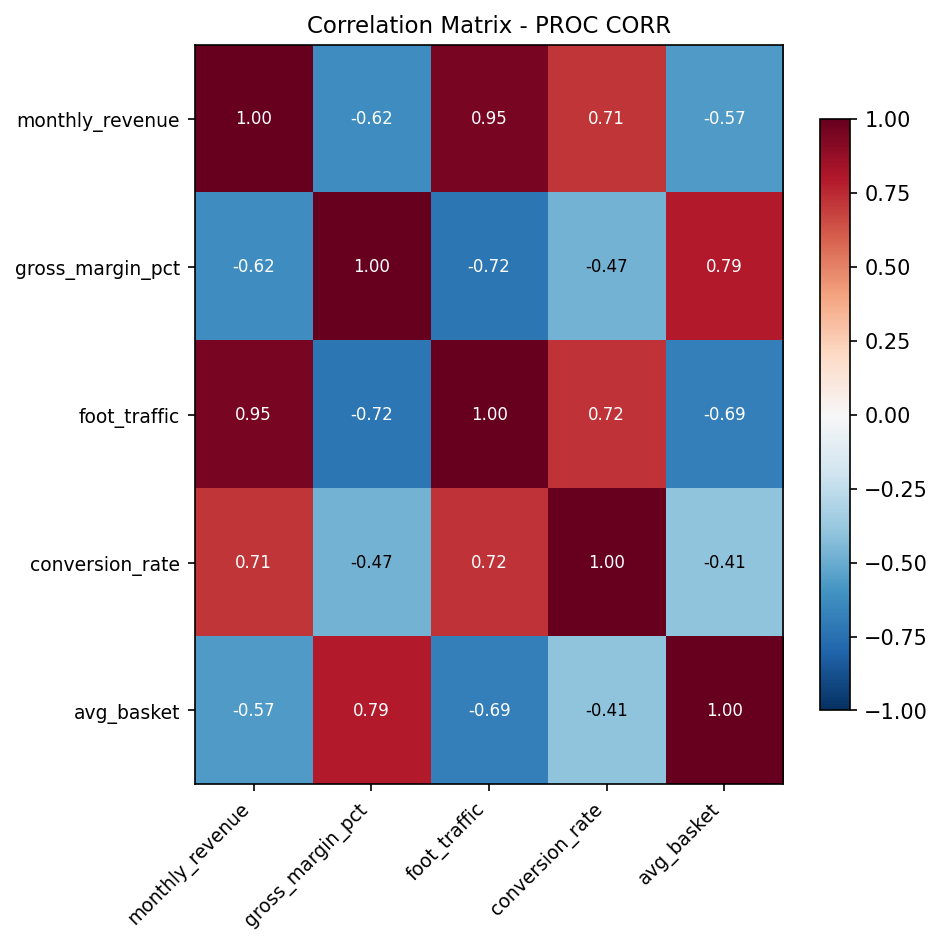

In [3]:
/* --------------------------------------------------------
   Correlation matrix heatmap of raw performance metrics
   -------------------------------------------------------- */
proc corr data=work.store_metrics nosimple noprob
    plots=matrix(histogram);
    var monthly_revenue gross_margin_pct foot_traffic
        conversion_rate avg_basket;
    title 'Store Performance Metric Correlations';
run;

---

In [4]:
/* --------------------------------------------------------
   Standardize all scorecard metrics to mean=0, std=1
   before principal component analysis
   -------------------------------------------------------- */
proc standard data=work.store_metrics
    out=work.metrics_standardized mean=0 std=1;
    var monthly_revenue gross_margin_pct foot_traffic
        conversion_rate avg_basket;
run;

NOTE: PROC STANDARD data=work.store_metrics

NOTE: Standardized 100 rows, 5 variables.


                       The PRINCOMP Procedure

                    Observations         100
                    Variables              5

                       Simple Statistics

Variable               Mean          StdDev

monthly_revenue    -0.00000         1.00000
gross_margin_pct   -0.00000         1.00000
foot_traffic       -0.00000         1.00000
conversion_rate     0.00000         1.00000
avg_basket          0.00000         1.00000

                    Correlation Matrix

                      monthly_revenue  gross_margin_pct  foot_traffic  conversion_rate  avg_basket

monthly_revenue                1.0000           -0.6192        0.9481           0.7145     -0.5663
gross_margin_pct              -0.6192            1.0000       -0.7249          -0.4739      0.7947
foot_traffic                   0.9481           -0.7249        1.0000           0.7223     -0.6851
conversion_rate                0.7145           -0.4739        0.7223           1.0000     -0.4054
avg_basket        

NOTE: PROC PRINCOMP data=work.metrics_standardized

NOTE: Using Python sklearn version 1.8.0
NOTE: Eigenvalues of the Correlation Matrix:
NOTE:   Prin1: Eigenvalue=3.683926  Proportion=0.7736  Cumulative=0.7736
NOTE:   Prin2: Eigenvalue=0.770217  Proportion=0.1617  Cumulative=0.9354
NOTE:   Prin3: Eigenvalue=0.307798  Proportion=0.0646  Cumulative=1.0000
NOTE: Eigenvectors:
NOTE:   Variable          Prin1      Prin2      Prin3
NOTE:   monthly_revenue   -0.472437   -0.307237   -0.542968
NOTE:   gross_margin_pct    0.438346   -0.470747   -0.205877
NOTE:   foot_traffic   -0.499722   -0.148211   -0.365394
NOTE:   conversion_rate   -0.400724   -0.571442    0.711274
NOTE:   avg_basket      0.417557   -0.579215   -0.152897
NOTE: Number of Observations: 100
NOTE: Analysis based on Correlation Matrix
NOTE: ODS plot written: princomp_scree.spec.json
NOTE: ODS plot written: princomp_scores.spec.json
NOTE: ODS plot written: princomp_patternprofile.spec.json
NOTE: PROC PRINCOMP ODS Graphics generat

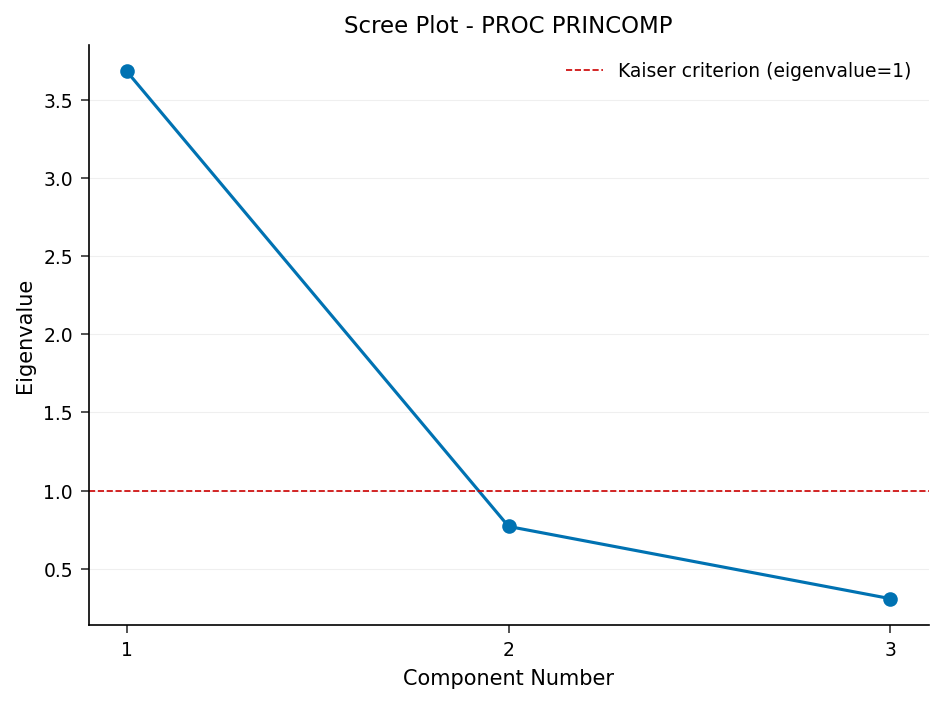

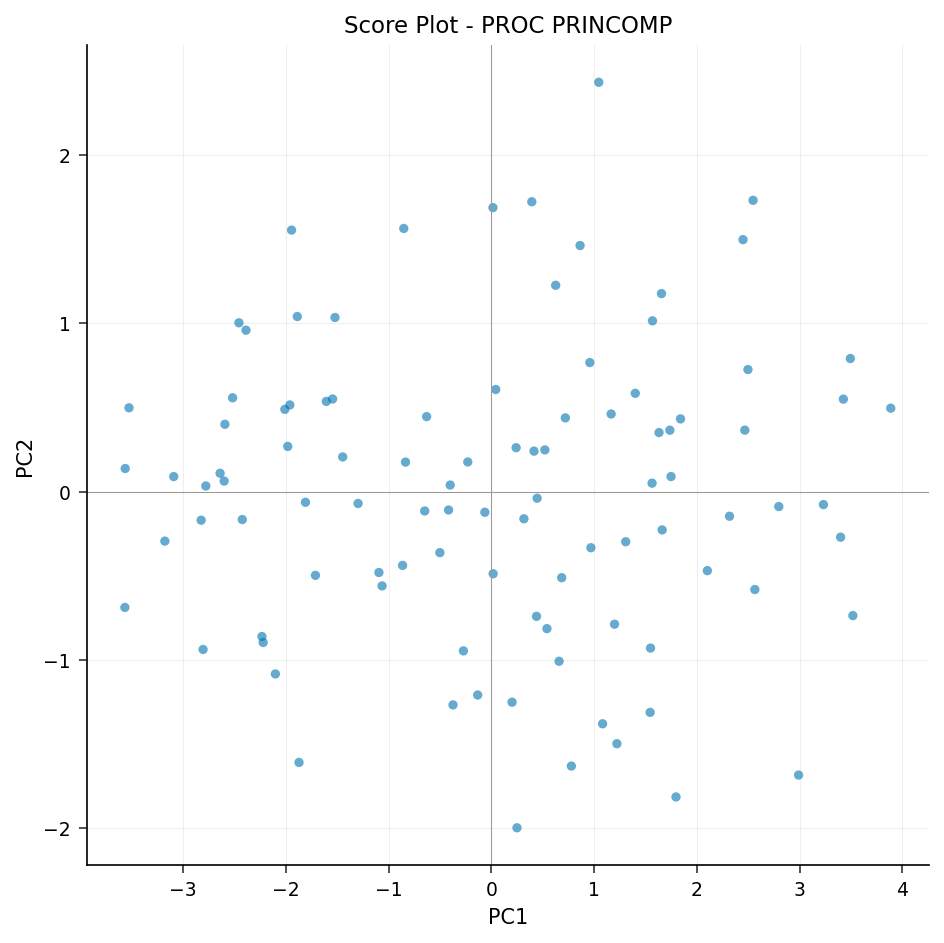

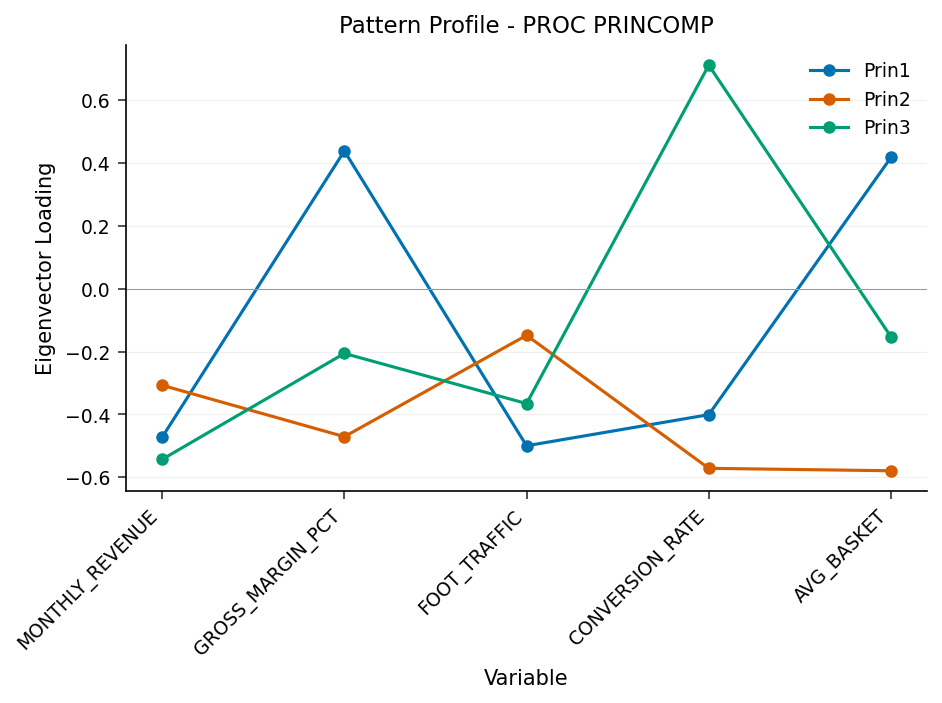

In [5]:
/* --------------------------------------------------------
   Principal component analysis on standardized metrics
   to extract latent performance dimensions
   -------------------------------------------------------- */
proc princomp data=work.metrics_standardized
    out=work.pca_scores n=3;
    var monthly_revenue gross_margin_pct foot_traffic
        conversion_rate avg_basket;
    title 'Principal Components of Store Performance';
run;

In [6]:
/* --------------------------------------------------------
   Summarize principal component scores by store format
   -------------------------------------------------------- */
proc means data=work.pca_scores n mean std;
    class store_format;
    var prin1 prin2 prin3;
run;

                                                  The MEANS Procedure

                                               Analysis Variable : Prin1

        STORE_FORMAT          N Obs           Mean        Std Dev
        ---------------------------------------------------------
        EXPRESS                  33      1.9747477      0.9864890
        STANDARD                 33      0.2016782      0.9243852
        SUPERSTORE               34     -2.1124134      0.8612191
        ---------------------------------------------------------

                                               Analysis Variable : Prin2

        STORE_FORMAT          N Obs           Mean        Std Dev
        ---------------------------------------------------------
        EXPRESS                  33      0.0049159      1.0159436
        STANDARD                 33     -0.0305039      0.9308746
        SUPERSTORE               34      0.0248354      0.6840517
        ----------------------------------------------

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Interpretation

The five scorecard metrics live on wildly different scales — revenue averages about $1.44M (std $498K) while conversion rate averages 21.8% (std 4.4 points). On raw values a principal component analysis would be governed almost entirely by revenue variance, so PROC STANDARD first rescales every metric to mean 0 and standard deviation 1. Standardization does not change the correlation structure, and that structure is strong: revenue and foot traffic move together (r = 0.95), gross margin and average basket move together (r = 0.79), and the two clusters oppose each other (traffic vs. margin r = -0.72). PROC PRINCOMP turns this into a compact set of latent performance dimensions.

The leading component is dominant: **PC1 carries 77% of the total variance** (eigenvalue 3.68), and PC1 together with **PC2 (16%) accounts for 94%**. PC1 contrasts the volume metrics — revenue, foot traffic, conversion — against the margin metrics — gross margin and average basket — so it reads as a single volume-versus-margin axis. PC2 (eigenvalue 0.77) loads in the same direction on gross margin, average basket, and conversion, capturing residual profitability and engagement that volume alone does not explain. PC3 (6%, eigenvalue 0.31) is almost entirely conversion rate, an operational-efficiency remainder.

Scoring the stores on these components cleanly separates the formats. Reading the mean PC1 score by store format, **SUPERSTORE locations anchor the high-volume / thin-margin pole** (mean PC1 -2.11; raw means: revenue $1.97M, traffic 28,300, but margin only 27.6% and basket $39.60), while **EXPRESS locations anchor the low-volume / high-margin pole** (mean PC1 +1.97; revenue $0.96M, traffic 10,100, yet margin 35.8% and basket $55.50). STANDARD stores sit in between on both metrics and near zero on PC1 (+0.20). This gives regional managers a balanced two-dimensional view of store performance — scale on one axis, profitability efficiency on the other — rather than a revenue-dominated single ranking, and the exported PC scores drop straight into the executive dashboard for format-level benchmarking.


---

In [7]:
/* --------------------------------------------------------
   Export PCA scores for executive dashboard
   -------------------------------------------------------- */
proc export data=work.pca_scores
    outfile='store_pca_scorecard.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.pca_scores outfile=store_pca_scorecard.csv

NOTE: Exported 100 rows to store_pca_scorecard.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>